## Polytope Climate-DT Bounding Box example notebook

This notebook shows how to use earthkit-data and earthkit-plots to pull destination-earth data from LUMI and plot it using earthkit-plot, as well as convert to geotiff both from full GRIB fields and extreacted bounding boxes.

Before running the notebook you need to set up your credentials. See the main readme of this repository for different ways to do this or use the following cells to authenticate.

You will need to generate your credentials using the desp-authentication.py script.

This can be run as follows:

In [ ]:
%%capture cap
%run ../../desp-authentication.py

This will generate a token that can then be used by earthkit and polytope.

In [ ]:
output_1 = cap.stdout.split('}\n')
access_token = output_1[-1][0:-1]

# Requirements
To run this notebook install the following:
* pip install earthkit-data
* pip install earthkit-plots
* pip install earthkit-regrid  (Optional for spectral variables)
* pip install cf-units         (Optional for unit conversion in maps)

If you do not have eccodes installed please install eccodes using conda as it is a dependency of earthkit, or install earthkit via conda

* conda install eccodes -c conda-forge
* conda install earthkit-data -c conda-forge

In [ ]:
import earthkit.data
import earthkit.plots
from earthkit.geo import regrid

In [ ]:
# Defaults to making a live data request. Set to false to use the cached GRIB file instead.
import os

LIVE_REQUEST = os.getenv("LIVE_REQUEST", "true").lower() == "true"
LIVE_REQUEST

In [ ]:
request = {
    "activity": "projections",
    "class": "d1",
    "dataset": "climate-dt",
    "experiment": "ssp3-7.0",
    "generation": "2",
    "levtype": "sfc",
    "date": "20400102",
    "model": "ifs-nemo",
    "expver": "0001",
    "param": "167/165",
    "realization": "1",
    "resolution": "standard",
    "stream": "clte",
    "type": "fc",
    "time": "0000",
    "feature": {
        "type": "boundingbox",
        "points" : [[55.1, 5.9], [47.3, 15.0]],
    },
}

In [ ]:
data_file = "../data/climate-dt-earthkit-geotiff.covjson"
if LIVE_REQUEST:
    data = earthkit.data.from_source("polytope", "destination-earth", request, address="polytope.mn5.apps.dte.destination-earth.eu", stream=False)
    with open(data_file, "w") as _f:
        data.to_target("file", _f)
else:
    data = earthkit.data.from_source("file", data_file) 

In [ ]:
ds = data.to_xarray()
ds

<xarray.Dataset> Size: 10kB
Dimensions:    (datetimes: 1, number: 1, steps: 1, points: 215)
Coordinates:
  * datetimes  (datetimes) <U20 80B '2040-01-02T00:00:00Z'
  * number     (number) int64 8B 0
  * steps      (steps) int64 8B 0
  * points     (points) int64 2kB 0 1 2 3 4 5 6 ... 208 209 210 211 212 213 214
    latitude   (points) float64 2kB 47.36 47.36 47.36 ... 54.72 54.72 54.72
    longitude  (points) float64 2kB 13.82 13.03 7.5 6.711 ... 6.158 7.105 14.68
    levelist   (points) float64 2kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    10u        (datetimes, number, steps, points) float64 2kB 0.6923 ... 9.793
    2t         (datetimes, number, steps, points) float64 2kB 262.7 ... 279.1
Attributes: (12/16)
    activity:       projections
    class:          d1
    dataset:        climate-dt
    Forecast date:  2040-01-02T00:00:00Z
    experiment:     ssp3-7.0
    expver:         0001
    ...             ...
    resolution:     standard
    stream:         clte
    type:           fc
    number:         0
    step:           0
    date:           2040-01-02T00:00:00Z

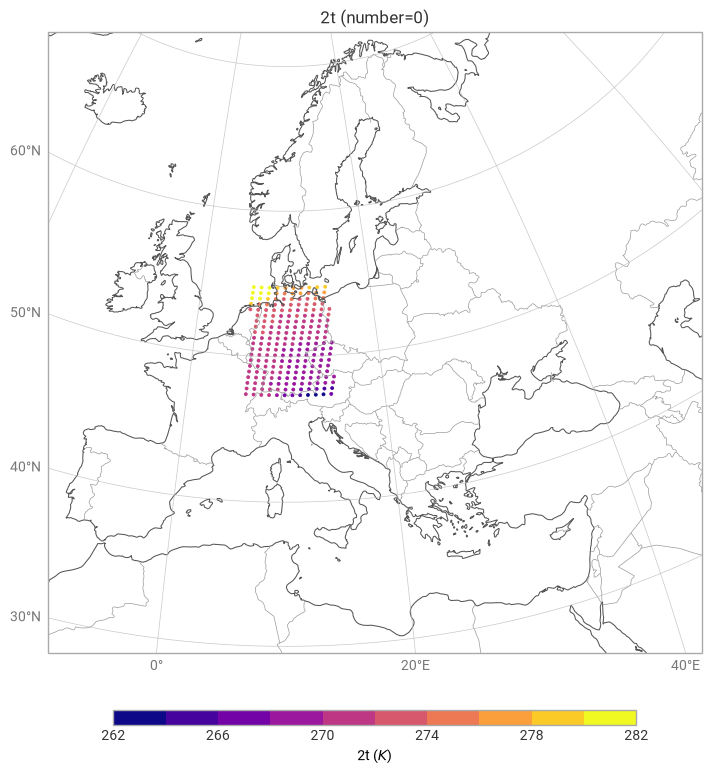

In [ ]:
chart = earthkit.plots.Map(domain="Europe")
chart.point_cloud(ds['2t'])

chart.coastlines()
chart.borders()
chart.gridlines()

chart.title("{variable_name} (number={number})")

chart.legend()

chart.show()

Extent: [5.900662251656, 15.000662251656, 47.300045049637, 55.060045049637]


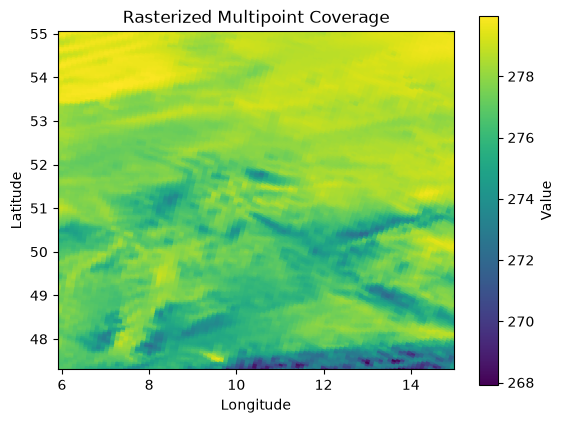

Band count: 1
Band 1: min=267.91541290283203, max=279.9843215942383


In [ ]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open("../data/multipoint_2t.tif") as src:
    data = src.read(1)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

print("Extent:", extent)

plt.imshow(data, extent=extent, origin="upper", cmap="viridis")
plt.colorbar(label="Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Rasterized Multipoint Coverage")
plt.savefig("../data/multipoint_2t.png")
plt.show()

with rasterio.open("../data/multipoint_2t.tif") as src:
    print("Band count:", src.count)
    for i in range(1, src.count + 1):
        arr = src.read(i)
        print(f"Band {i}: min={arr.min()}, max={arr.max()}")

This file can then be uploaded as user data on the DestinE story editor here https://dea.destine.eu/web/stories/editor, and plotted on a 3d globe.

## Full Field Extraction and conversion to GeoTIFF

In [ ]:
request = {
    "activity": "projections",
    "class": "d1",
    "dataset": "climate-dt",
    "experiment": "ssp3-7.0",
    "generation": "2",
    "levtype": "sfc",
    "date": "20400102",
    "model": "ifs-nemo",
    "expver": "0001",
    "param": "167/165",
    "realization": "1",
    "resolution": "standard",
    "stream": "clte",
    "type": "fc",
    "time": "0000",
}

In [ ]:
data_file = "../data/climate-dt-earthkit-geotiff_2.grib"
if LIVE_REQUEST:
    data = earthkit.data.from_source("polytope", "destination-earth", request, address="polytope.mn5.apps.dte.destination-earth.eu", stream=False)
    data.to_target("file", data_file)
else:
    data = earthkit.data.from_source("file", data_file) 

In [ ]:
df = data.to_fieldlist()
df.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,2t,2040-01-02,2040-01-02,0 days,2,height_above_ground_level,None,healpix
1,10u,2040-01-02,2040-01-02,0 days,10,height_above_ground_level,None,healpix


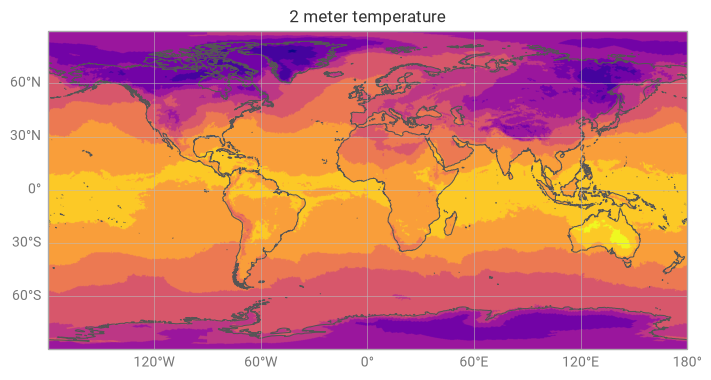

In [ ]:
chart = earthkit.plots.Map(extent=[-180, 180, -90, 90])
chart.grid_cells(
    df[0],
)

chart.title("2 meter temperature")
chart.coastlines()
chart.gridlines()
chart.show()

Data must be converted from HEALPIX first as we cannot convert to GeoTIFF directly.

In [ ]:
data_latlon = regrid(
    df,
    out_grid={"grid": [1,1]},
    interpolation="linear"
)

In [ ]:
data_latlon.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,2t,2040-01-02,2040-01-02,0 days,2,height_above_ground_level,None,regular_ll
1,10u,2040-01-02,2040-01-02,0 days,10,height_above_ground_level,None,regular_ll


In [ ]:
data_latlon.to_target("file", "../data/_test.tiff")


In [ ]:
ds1 = earthkit.data.from_source("file", "../data/_test.tiff")
df1 = ds1.to_fieldlist()
df1.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,10 metre U wind component,None,None,None,None,unknown,None,None
1,2 metre temperature,None,None,None,None,unknown,None,None
